In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
employees = pd.DataFrame({
    "EmpID": [101,102,103,104,105,106,107,108],
    "EmpName": ["Amit","Ravi","Neha","Pooja","Karan","Sneha","Vikas","Anjali"],
    "Department": ["IT","HR","IT","Finance","HR","Finance","IT","HR"],
    "Location": ["BLR","MUM","BLR","DEL","MUM","DEL","BLR","MUM"],
    "Salary": [60000,90000,75000,65000,50000,95000,85000,52000]
})
employees

,EmpID,EmpName,Department,Location,Salary
0,101,Amit,IT,BLR,60000
1,102,Ravi,HR,MUM,90000
2,103,Neha,IT,BLR,75000
3,104,Pooja,Finance,DEL,65000
4,105,Karan,HR,MUM,50000
5,106,Sneha,Finance,DEL,95000
6,107,Vikas,IT,BLR,85000
7,108,Anjali,HR,MUM,52000


In [3]:
audit = pd.DataFrame({
    "EmpID": [101,102,103,104,105,106,107,108],
    "Audit_Type": ["Internal","Internal","External","Internal","External","External","Internal","External"],
    "Audit_Score": [85,78,92,88,70,95,80,75],
    "Compliance_Status": ["Pass","Pass","Pass","Pass","Fail","Pass","Pass","Fail"],
    "Audit_Month": ["Jan","Jan","Feb","Feb","Mar","Mar","Jan","Feb"]
})
audit

,EmpID,Audit_Type,Audit_Score,Compliance_Status,Audit_Month
0,101,Internal,85,Pass,Jan
1,102,Internal,78,Pass,Jan
2,103,External,92,Pass,Feb
3,104,Internal,88,Pass,Feb
4,105,External,70,Fail,Mar
5,106,External,95,Pass,Mar
6,107,Internal,80,Pass,Jan
7,108,External,75,Fail,Feb


In [4]:
# Q1. Combine employee and audit data

combined_data = employees.merge(audit,on="EmpID",how="left")
combined_data

,EmpID,EmpName,Department,Location,Salary,Audit_Type,Audit_Score,Compliance_Status,Audit_Month
0,101,Amit,IT,BLR,60000,Internal,85,Pass,Jan
1,102,Ravi,HR,MUM,90000,Internal,78,Pass,Jan
2,103,Neha,IT,BLR,75000,External,92,Pass,Feb
3,104,Pooja,Finance,DEL,65000,Internal,88,Pass,Feb
4,105,Karan,HR,MUM,50000,External,70,Fail,Mar
5,106,Sneha,Finance,DEL,95000,External,95,Pass,Mar
6,107,Vikas,IT,BLR,85000,Internal,80,Pass,Jan
7,108,Anjali,HR,MUM,52000,External,75,Fail,Feb


In [5]:
# QUESTION 2 — Average Audit Score by Department

combined_data.groupby("Department")["Audit_Score"].mean()

Department
Finance    91.500000
HR         74.333333
IT         85.666667
Name: Audit_Score, dtype: float64

In [6]:
# QUESTION 3 — Department × Audit Type (Pivot logic)

combined_data.groupby(["Department","Audit_Type"])["Audit_Score"].mean().unstack(fill_value=0)

Audit_Type,External,Internal
Department,,
Finance,95.0,88.0
HR,72.5,78.0
IT,92.0,82.5


In [7]:
# QUESTION 4 — Count of Audits per Month

combined_data.groupby("Audit_Month").size()

Audit_Month
Feb    3
Jan    3
Mar    2
dtype: int64

In [9]:
# QUESTION 5 — Compliance Pass vs Fail (Counts)

combined_data.groupby("Compliance_Status").size().sort_values(ascending=False)

Compliance_Status
Pass    6
Fail    2
dtype: int64

In [14]:
# QUESTION 6 — Compliance % by Department

comp = combined_data.groupby(["Department","Compliance_Status"])["Audit_Score"].size().unstack(fill_value=0)
comp["compliance%"] = comp["Pass"]/ comp.sum(axis=1)*100
comp

Compliance_Status,Fail,Pass,compliance%
Department,,,
Finance,0,2,100.000000
HR,2,1,33.333333
IT,0,3,100.000000


In [17]:
# QUESTION 7 — High Salary but Failed Audit

combined_data[combined_data["Compliance_Status"] == "Fail"].sort_values("Salary",ascending=False)

,EmpID,EmpName,Department,Location,Salary,Audit_Type,Audit_Score,Compliance_Status,Audit_Month
7,108,Anjali,HR,MUM,52000,External,75,Fail,Feb
4,105,Karan,HR,MUM,50000,External,70,Fail,Mar


In [20]:
# QUESTION 8 — Identify High-Risk Employees (Rule-based)Definition:External audit, Score < 80, Compliance = Fail

combined_data[
    (combined_data["Audit_Type"] == "External") &
    (combined_data["Audit_Score"] < 80) &
    (combined_data["Compliance_Status"] == "Fail")
]

,EmpID,EmpName,Department,Location,Salary,Audit_Type,Audit_Score,Compliance_Status,Audit_Month
4,105,Karan,HR,MUM,50000,External,70,Fail,Mar
7,108,Anjali,HR,MUM,52000,External,75,Fail,Feb


In [22]:
# QUESTION 9 - Audit score by dept visual

combined_data.groupby("Department")["Audit_Score"].mean()

Department
Finance    91.500000
HR         74.333333
IT         85.666667
Name: Audit_Score, dtype: float64

<Axes: xlabel='Department'>

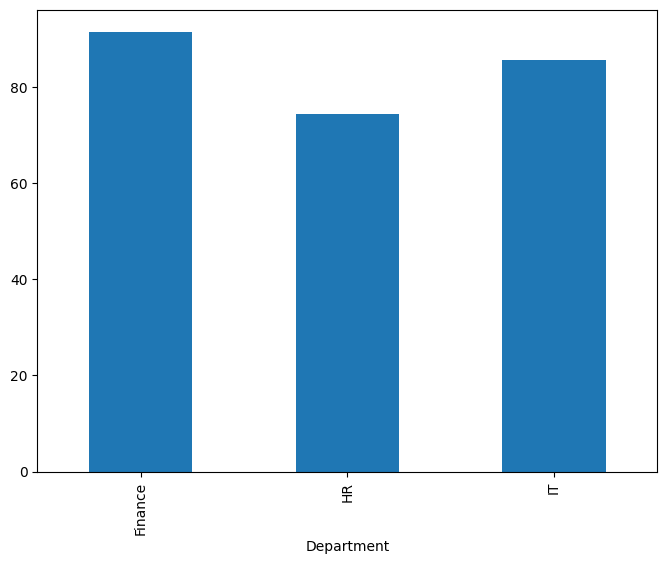

In [25]:
# QUESTION 9 — Avg Audit Score by Department (Bar Chart)

combined_data.groupby("Department")["Audit_Score"].mean().plot(kind= "bar",figsize=(8,6))

<Axes: xlabel='Audit_Month'>

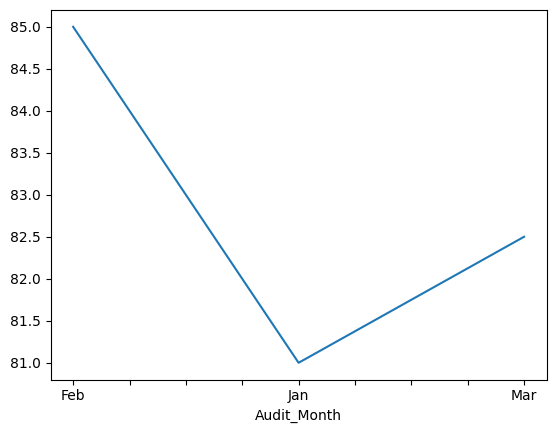

In [26]:
# QUESTION 10 — Audit Trend over Time

combined_data.groupby("Audit_Month")["Audit_Score"].mean().plot()

In [28]:
# QUESTION 11 — ANOVA Do audit scores differ by department?

from scipy.stats import f_oneway

f_oneway(
    combined_data[combined_data["Department"] == "IT"]["Audit_Score"],
    combined_data[combined_data["Department"] == "HR"]["Audit_Score"],
    combined_data[combined_data["Department"] == "Finance"]["Audit_Score"],
)

F_onewayResult(statistic=7.529685494223365, pvalue=0.031019281538091973)

In [31]:
# QUESTION 12 — Chi-Square Is compliance dependent on audit type?

from scipy.stats import chi2_contingency

table = pd.crosstab(combined_data["Audit_Type"],combined_data["Compliance_Status"])
chi2_contingency(table)

Chi2ContingencyResult(statistic=0.6666666666666666, pvalue=0.4142161782425251, dof=1, expected_freq=array([[1., 3.],
       [1., 3.]]))

<Axes: title={'center': 'Audit_Score'}, xlabel='Department'>

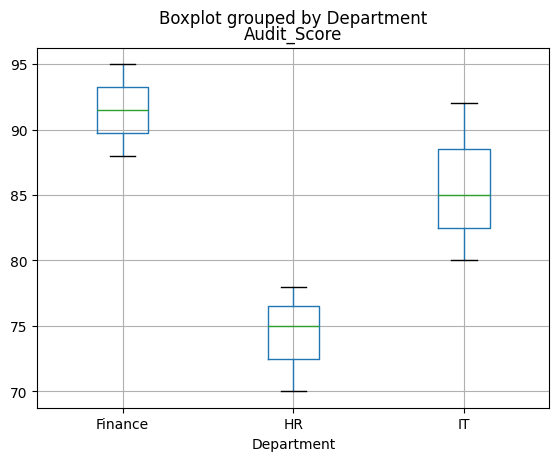

In [32]:
# QUESTION 13 - Boxplot

combined_data.boxplot(
    column="Audit_Score",
    by= "Department"
)

<Axes: >

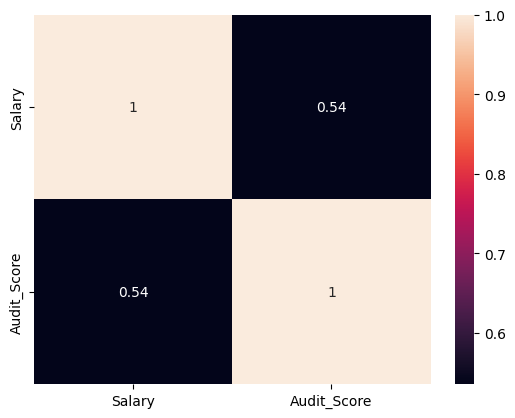

In [37]:
# QUESTION 14 - Correlation between salary and Score

sns.heatmap(combined_data[["Salary", "Audit_Score"]].corr(),annot=True)

In [39]:
# QUESTION 15 — Which department contributes MOST to overall audit risk?

combined_data[combined_data["Compliance_Status"] == "Fail"].groupby("Department").size()

Department
HR    2
dtype: int64

In [42]:
# QUESTION 16 — Which audit type is MORE volatile (inconsistent)?

combined_data.groupby("Audit_Type")["Audit_Score"].std()

Audit_Type
External    12.355835
Internal     4.573474
Name: Audit_Score, dtype: float64

<Axes: title={'center': 'Audit_Score'}, xlabel='Audit_Type'>

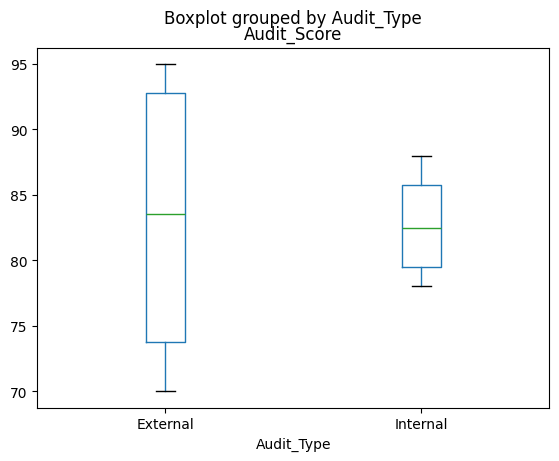

In [46]:
combined_data.boxplot(
    column="Audit_Score",
    by= "Audit_Type",
    grid=False
)

In [58]:
# QUESTION 17 — Are high-salary employees actually safer?

combined_data["Salary_Band"] = pd.cut(
    combined_data["Salary"],
    bins= [0,60000,80000,100000],
    labels=["Low","Medium","High"]
)

pd.crosstab(
    combined_data["Salary_Band"],
    combined_data["Compliance_Status"],
    normalize="index"
)*100

Compliance_Status,Fail,Pass
Salary_Band,,
Low,66.666667,33.333333
Medium,0.000000,100.000000
High,0.000000,100.000000


<Axes: xlabel='Salary_Band'>

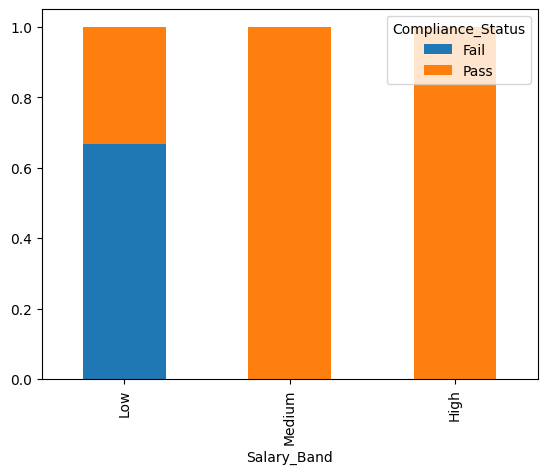

In [60]:
pd.crosstab(
    combined_data["Salary_Band"],
    combined_data["Compliance_Status"],
    normalize="index"
).plot(kind="bar",stacked=True)

In [72]:
# QUESTION 18 — Which department is improving or deteriorating over time?

combined_data.groupby(["Department","Audit_Month"])["Audit_Score"].mean().unstack(fill_value=0)

Audit_Month,Feb,Jan,Mar
Department,,,
Finance,88.0,0.0,95.0
HR,75.0,78.0,70.0
IT,92.0,82.5,0.0


<Axes: xlabel='Audit_Month'>

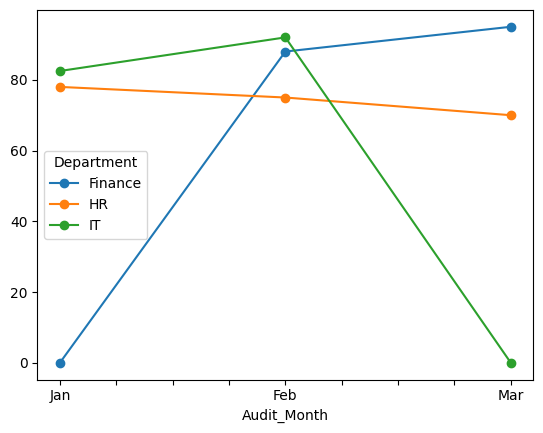

In [79]:
combined_data.groupby(["Audit_Month","Department"])["Audit_Score"].mean().unstack(fill_value=0).reindex(["Jan","Feb","Mar"]).plot(marker="o")

In [86]:
# QUESTION 19 — Identify control gaps (Low score + Pass status)

combined_data[
    (combined_data["Audit_Score"] < 80) &
    (combined_data["Compliance_Status"] == "Pass")
    ][["EmpID","Department","Audit_Score","Compliance_Status"]]

,EmpID,Department,Audit_Score,Compliance_Status
1,102,HR,78,Pass


<Axes: xlabel='Department'>

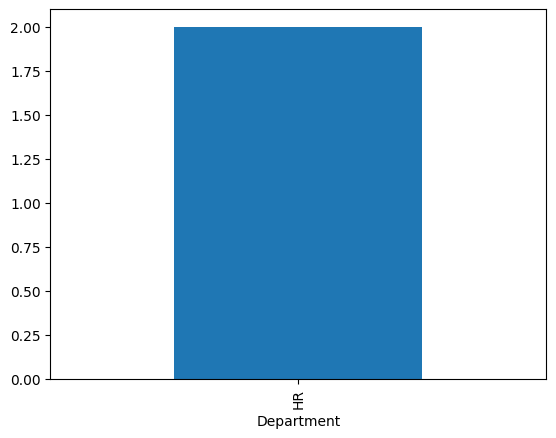

In [88]:
# QUESTION 20 — Pareto Analysis: Who drives most failures?

pareto = combined_data[combined_data["Compliance_Status"]=="Fail"] \
    .groupby("Department") \
    .size() \
    .sort_values(ascending=False)

pareto.plot(kind="bar")

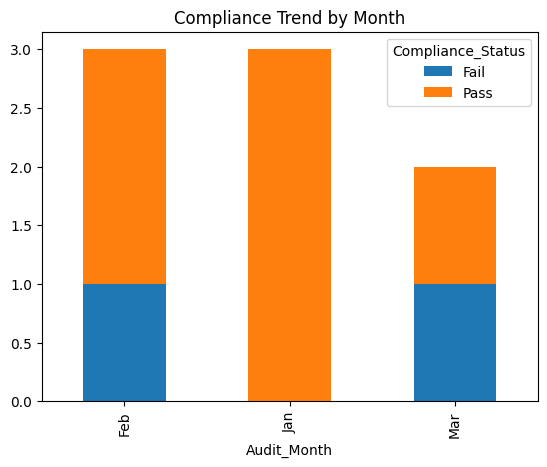

In [89]:
# QUESTION 21 — Does audit month influence compliance?

pd.crosstab(
    combined_data["Audit_Month"],
    combined_data["Compliance_Status"],
    normalize="index"
) * 100

pd.crosstab(
    combined_data["Audit_Month"],
    combined_data["Compliance_Status"]
).plot(kind="bar", stacked=True)

plt.title("Compliance Trend by Month")
plt.show()